In [32]:
import os
import re
import sys
import json
import pickle
import importlib
import itertools
import subprocess
import numpy as np
import pandas as pd
import nibabel as nib

sys.path.append('/host/verges/tank/data/daniel/00_commonUtils/00_code/genUtils/')
import t1, gen

import visUtils as vis
import statsUtils
import projectUtils as prjUtils


In [101]:
# parameters

AP_coords_pth = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/coordinates/coords-AntPost_sub-PNC027_ses-a1_hemi-L_ctxSurf-fsLR-32k_ctxLbl-pial_hippSurf-den-0p5mm_hippLbl-inner_stitched_13Mar2026-1810_mask-mTemp.func.gii"
AN_coords_pth = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/coordinates/coords-AlloNeo_sub-PNC027_ses-a1_hemi-L_ctxSurf-fsLR-32k_ctxLbl-pial_hippSurf-den-0p5mm_hippLbl-inner_stitched_13Mar2026-1810_mask-mTemp.func.gii"
AP_annots = ['Posterior','Anterior'] # low values, high values
AN_annots = [f'Dentate\ngyrus','Neocortex'] # low values, high values

surf_mask_info = {
    'dir_root': '/host/verges/tank/data/daniel/04_inVivoHistology/code/resources',
    'maskName': 'Mesial Temporal Mask',
    'maskSuffix': 'mTemp',
    'surf_stitch_template': "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/templates/overlap_stitch_template_JD_Jan2026.pkl",
    'surfs_stitched_mask': "ctxSurf-fsLR-32k_ctxLbl-pial_hippSurf-den-0p5mm_hippLbl-inner_stitched_13Mar2026_mask-mTempClean.label.gii",
    'surfs_stitched_lbls': "labels_stitch_ctx-Destrieux_hipp-DK25_13Mar2026_mask-mTempClean.label.gii",
    'surfs_stitched_lut': "lut_stitch_ctx-Destrieux_hipp-DK25_13Mar2026.csv",
}

dirs_project = {
    'dir_root': '/host/verges/tank/data/daniel/04_inVivoHistology',
    'dir_data': 'data/',
    'dir_out': 'outputs/',
    'demo_dfs': 'demo_dfs',
    'figs': 'figs',
    'pathLists': 'pathLists',
}

analysis_params = {
    
    'time': '09Apr2026-1204', # for file naming
    
    'verbose': True,
    'qMap_names':["T1map"], # names of qMAP of interest
    
    'ctrl_grp':"CTRL_match", # reference to Z score on
    'test_grps': ["TLE_L", "TLE_R", "TLE_LR"], # groups to compare to reference for Z score (excluding the ctrl_grp)
    
    'icFlip': True,
    'ipsiTo': 'L',
    'contraTo': 'R',
    
    'nSurfs':16,
    'smoothing':["0", "0p5"],

    'equiVol_str': "equivol",
}

# for surface visualizations
example_surf_l = "/host/verges/tank/data/daniel/04_inVivoHistology/data/PNI/sub-PNC045_ses-a1/surfs/sub-PNC045_ses-a1_hemi-L_09Apr2026-1204_equivol-2of16.surf.gii"
example_surf_r = "/host/verges/tank/data/daniel/04_inVivoHistology/data/PNI/sub-PNC045_ses-a1/surfs/sub-PNC045_ses-a1_hemi-R_09Apr2026-1204_equivol-2of16.surf.gii"

faces_l = nib.load(example_surf_l).darrays[1].data
vertices_l = nib.load(example_surf_l).darrays[0].data

faces_r = nib.load(example_surf_r).darrays[1].data
vertices_r = nib.load(example_surf_r).darrays[0].data

demo_dicts_json_pth = os.path.join(dirs_project['dir_root'], dirs_project['dir_out'], f"grp_dicts_{analysis_params['time']}.json" )
print(f"\nLoading dict_list ({gen.fmt_file_size(demo_dicts_json_pth)}): {demo_dicts_json_pth}")
with open(demo_dicts_json_pth, 'r') as f:
    dict_list = json.load(f)

study_dicts = [
    { # MICS
        'studyName': 'MICs',
        'studyDescrip': '3T',
        'dir_root': '/data/mica3/BIDS_MICs/',
        'dir_raw': 'rawdata/',
        'dir_deriv': 'derivatives/',
        'dir_fs': 'freesurfer/',
        'dir_mp': 'micapipe_v0.2.0/',
        'dir_hu': 'hippunfold_v1.3.0/hippunfold/', # update to v2?
    },
    { # PNI
        'studyName': 'PNI',
        'studyDescrip': '7T',
        'dir_root': '/data/mica3/BIDS_PNI/',
        'dir_raw': 'rawdata/',
        'dir_deriv': 'derivatives/',
        'dir_fs': 'fastsurfer/',
        'dir_mp': 'micapipe_v0.2.0/',
        'dir_hu': 'hippunfold_v1.3.0/hippunfold/', # update to v2?

        'dir_root_pilot': '/host/verges/tank/data/MICA-7T-pilot/',
        'dir_deriv_pilot': 'derivatives/',
        'dir_mp_pilot': 'micapipe/',
    }
]

# Initialize, load
path_list_dir = os.path.join(dirs_project['dir_root'], dirs_project['dir_out'], 'group_maps', analysis_params['time'], dirs_project['pathLists'])
an_coords = nib.load(AN_coords_pth).darrays[0].data
ap_coords = nib.load(AP_coords_pth).darrays[0].data


Loading dict_list (17KB): /host/verges/tank/data/daniel/04_inVivoHistology/outputs/grp_dicts_09Apr2026-1204.json


In [34]:
# Demographic summary
print(f"\nDemographic summary ({demo_dicts_json_pth})")
list_grps = [[d['group'], pd.read_csv(d['demo_df_pth'])] for d in dict_list] # list of [names, demo_df]
t1.summarize_grps(list_grps, toPrint=False)


Demographic summary (/host/verges/tank/data/daniel/04_inVivoHistology/outputs/grp_dicts_09Apr2026-1204.json)


,Group,n_unique,n_SES,Sex_percF,Sex_F,Sex_M,Age_min,Age_25p,Age_mean,Age_median,Age_75p,Age_max,Age_std,Age_IQR
0,CTRL,49.0,49.0,51.020408,25.0,24.0,20.2,26.30,29.397143,27.80,31.500,42.8,5.387101,5.200
1,TLE_L,10.0,10.0,50.000000,5.0,5.0,29.8,30.75,36.510000,32.65,36.500,61.2,9.687730,5.750
2,TLE_R,10.0,10.0,90.000000,9.0,1.0,20.4,24.10,34.120000,33.65,42.925,49.7,10.824335,18.825
3,TLE_LR,20.0,20.0,70.000000,14.0,6.0,20.4,30.40,35.315000,32.65,42.175,61.2,10.072698,11.775
4,CTRL_match,33.0,33.0,51.515152,17.0,16.0,24.5,27.10,31.152121,30.30,34.620,42.8,5.371862,7.520
5,all,69.0,122.0,56.521739,39.0,30.0,20.2,26.40,31.112464,29.10,34.620,61.2,7.493259,8.220


In [ ]:
# Show axes
# based on an example surface
importlib.reload(vis)

_ = vis.show_mesh_map(vertices_l, faces_l, values = an_coords, title = f"Allo-Neo coordinates", label_vals = "Distance from dentate gyrus (mm)")
_ = vis.show_mesh_map(vertices_l, faces_l, values = ap_coords, title = f"Ant-Post coordinates", label_vals = "MRI's y-axis (mm)")

Widget(value='<iframe src="http://localhost:38357/index.html?ui=P_0x7fc1f8453550_12&reconnect=auto" class="pyv…

Widget(value='<iframe src="http://localhost:38357/index.html?ui=P_0x7fc1f7882390_13&reconnect=auto" class="pyv…

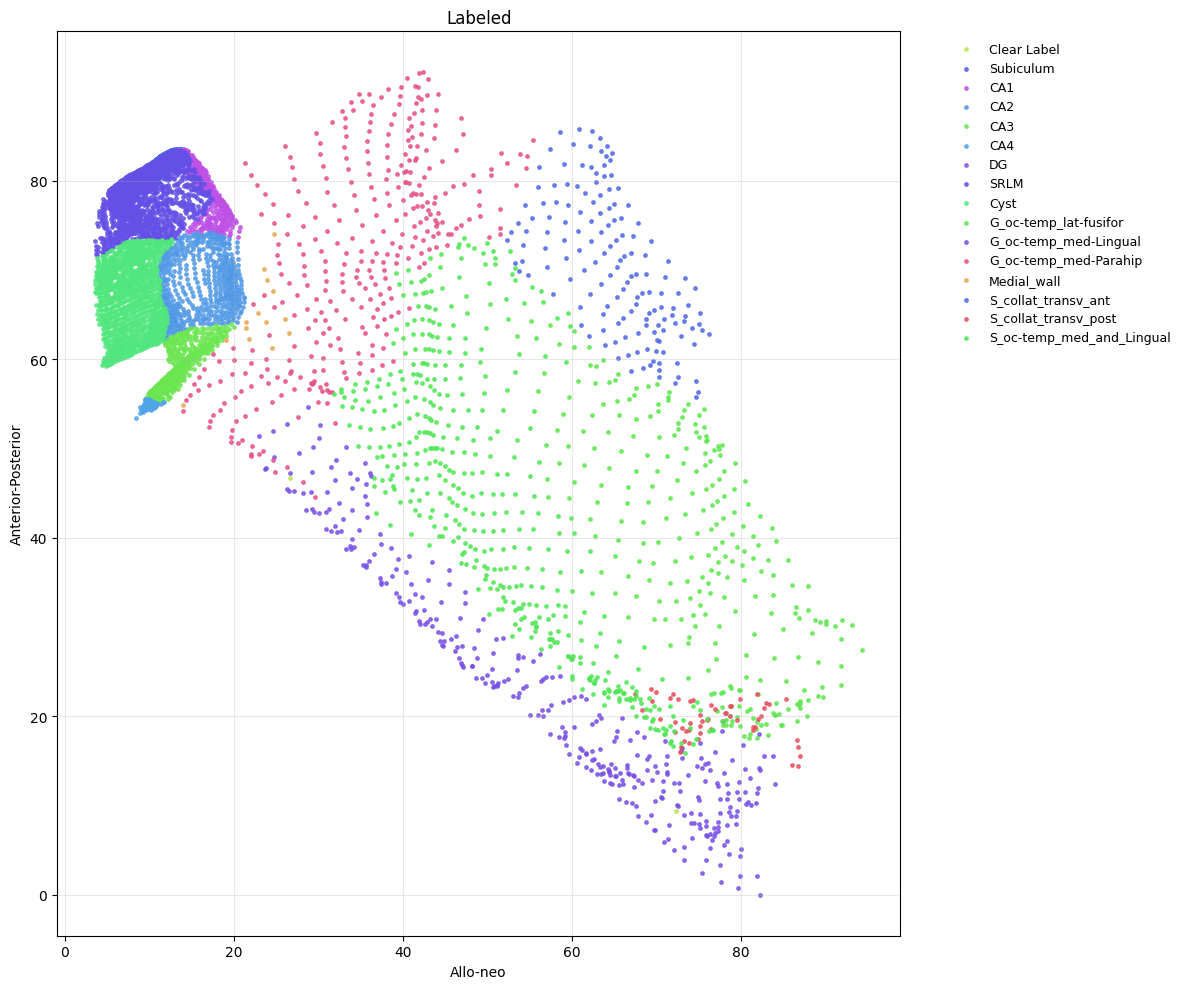

In [44]:
# Show labels
importlib.reload(vis)
label_data = nib.load(os.path.join(surf_mask_info['dir_root'], surf_mask_info['surfs_stitched_lbls'])).darrays[0].data
lbl_remove = ['Cyst']
_ = vis.visualize_label(
    x_coord_data = an_coords, x_coord_name = "Allo-neo", 
    y_coord_data = ap_coords, y_coord_name = "Anterior-Posterior", 
    label_data = label_data, lut_csv_pth = os.path.join(surf_mask_info['dir_root'],surf_mask_info['surfs_stitched_lut']),
    lbl_value_col="idx", lbl_name_col="label", map_name="Labeled", cmap='tab10',
    lbl_remove=None)

In [ ]:
# SHOW PROFILES [AVERGAE BY GROUP]
# TODO. SHOW cortical thickness of each vertex; need to compute for each ind
# TODO. Draw aline following the first moment across the vertices

importlib.reload(prjUtils)
pts_seen = []
statNames = ['raw']
date, equiVolStr, nSurfs, mapNames, smoothing, override, verbose = prjUtils.extract_analysis_params(analysis_params)
hemi_a = "ipsi"

ap_coords = nib.load(AP_coords_pth).darrays[0].data
sort_axis = ap_coords
values_min, values_max = 1000, 3200

bin_along_axis = True
bin_width = 1 # mm, to combine vertices at similar values along the axis of interest

for mapName, grpInfo in itertools.product(mapNames, dict_list):
    grp = grpInfo['group']
    
    if grp in [analysis_params['ctrl_grp']] + analysis_params['test_grps'] and grp != "TLE_LR":
        print(f"{'-'*40}\n{grp}")
        df = pd.read_csv(grpInfo['demo_df_pth'])
        if grp == [analysis_params['ctrl_grp']]:
            hemi_a = analysis_params['ipsiTo']
            hemi_b = analysis_params['contraTo']
        else:
            hemi_a = "ipsi"
            hemi_b = "contra"

        for statName, smth in itertools.product(statNames, smoothing):
            if statName == "raw":
                data_path_a = os.path.join(prjUtils.get_aggregateMapDir(dirs_project, date, grp),
                                          prjUtils.get_pkl_3Darray_maps_name(grp, hemi_a, mapName, equiVolStr, nSurfs, smth, date))
                data_path_b = os.path.join(prjUtils.get_aggregateMapDir(dirs_project, date, grp),
                                          prjUtils.get_pkl_3Darray_maps_name(grp, hemi_b, mapName, equiVolStr, nSurfs, smth, date))
                
            else:
                data_path_a = os.path.join(prjUtils.get_statSavePath(dirs_project=dirs_project, date=date, grp=grp), 
                                              prjUtils.get_stat_save_name(grp = grp, hemi = hemi_a, date= date, equiVolStr=equiVolStr, nSurfs=str(nSurfs), mapName=mapName, smth=smth, stat = statName, ext="pickle"))
                data_path_b = os.path.join(prjUtils.get_statSavePath(dirs_project=dirs_project, date=date, grp=grp), 
                                              prjUtils.get_stat_save_name(grp = grp, hemi = hemi_b, date= date, equiVolStr=equiVolStr, nSurfs=str(nSurfs), mapName=mapName, smth=smth, stat = statName, ext="pickle"))
            
            if not os.path.exists(data_path_a):
                print(f"File not found. Skipping.")
                continue

            print(f"Loading {gen.fmt_file_size(data_path_a)}: {data_path_a}")
            print(f"Loading {gen.fmt_file_size(data_path_b)}: {data_path_b}")
            data_a = prjUtils.read_pkl(data_path_a)
            data_b = prjUtils.read_pkl(data_path_b)
            
            if type(data_a) != dict:
                # TO IMPPLEMENT
                pass
            else:
                data_a_df = data_a['df']

            if type(data_b) != dict:
                pass
            else:
                data_b_df = data_b['df']
            
            
            for subj in range(data_a['df'].shape[1]):
                vertex_order = np.argsort(sort_axis.ravel())  # Get indices sorted by axis values
                
                subj_a = data_a_df[:,subj,:]
                subj_b = data_b_df[:,subj,:]
                
                subj_a_sorted = subj_a[:,vertex_order]
                subj_b_sorted = subj_b[:,vertex_order]

                if bin_along_axis:
                    subj_a_sorted, subj_b_sorted, bin_centers = vis.bin_by_axis_width(
                        sort_axis, data_a_df, data_b_df, subj, bin_width=bin_width
                    )

                # Visualize sorted data
                side_a = {
                    'data':subj_a_sorted,
                    'hemi_lbl': hemi_a
                    }
                side_b = {
                    'data':subj_b_sorted,
                    'hemi_lbl': hemi_b
                    }
                
                assert data_a['idx_dim1'][subj] == data_b['idx_dim1'][subj], f"ERROR. The patient data is mismatched between hemis a:{data_a['idx_dim1'][subj]} != b:{data_b['idx_dim1'][subj]}"
                if bin_along_axis:
                    vis.showProfile_hemi(side_a, side_b, x_vals = bin_centers, x_label = "AP axis", legend=f"stat-{statName}", title=f"{data_b['idx_dim1'][subj]}\n{mapName}-{smth}mm [{bin_width}mm bins]", vmin = values_min, vmax = values_max)
                else:
                    vis.showProfile_hemi(side_a, side_b, x_vals = sort_axis, x_label = "AP axis", legend=f"stat-{statName}", title=f"{data_b['idx_dim1'][subj]}\n{mapName}-{smth}mm", vmin = values_min, vmax = values_max)
                break

            break

[read_pkl] Loaded (4KB): /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/pathLists/gradient_aligned_dict_paths_byGroup.pkl
[read_pkl] Loaded (4KB): /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/pathLists/moment_dict_paths_byGroup.pkl
[read_pkl] Loaded (2KB): /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/pathLists/ipsicontra_moments_gradients_dicts_byGroup.pkl
----------
CTRL - T1map (smth=0): Data shape (6, 49, 8853)
[gradients-aligned] Skipping (vis_rawValues setting)
----------
CTRL - T1map (smth=0p5): Data shape (6, 49, 8853)
[gradients-aligned] Skipping (vis_rawValues setting)
----------
TLE_L - T1map (smth=0): Data shape (6, 10, 8853)
[gradients-aligned] Skipping (vis_rawValues setting)
----------
TLE_L - T1map (smth=0p5): Data shape (6, 10, 8853)
[gradients-aligned] Skipping (vis_rawValues setting)
----------
TLE_R - T1map (smth=0): Data shape (6, 10, 8853)
[gradients-alig

KeyboardInterrupt: 

: 

[read_pkl] Loaded (4KB): /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/pathLists/gradient_aligned_dict_paths_byGroup.pkl
[read_pkl] Loaded (4KB): /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/pathLists/moment_dict_paths_byGroup.pkl
[read_pkl] Loaded (2KB): /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/pathLists/ipsicontra_moments_gradients_dicts_byGroup.pkl


['/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/CTRL/stats/grp-CTRL_hemi-L_09Apr2026-1204_equivol-allof16_map-T1map_smth-0mm_stat-gradients-aligned-dict.pkl',
 '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/CTRL/stats/grp-CTRL_hemi-R_09Apr2026-1204_equivol-allof16_map-T1map_smth-0mm_stat-gradients-aligned-dict.pkl',
 '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/CTRL/stats/grp-CTRL_hemi-L_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-dict.pkl',
 '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/CTRL/stats/grp-CTRL_hemi-R_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-dict.pkl',
 '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/TLE_L/stats/grp-TLE_L_hemi-L_09Apr2026-1204_equivol-allof16_map-T1map_smth-0mm_stat-gradients-aligned-dict.pkl',
 '/host/verges

In [ ]:
# Visualize gradients by group
importlib.reload(vis)
importlib.reload(statsUtils)
importlib.reload(prjUtils)

# visulaization parameters
vis_rawValues = {
    'flip_an_coords':True,
    'flip_ap_coords': False,
    'overwrite': True, # whether to overwrite existing visualizations

    'grads':{
        'skip': False,
        'flip_values': True,
        'idx_retained':[1], # what gradient indices to visualize
        
        'scree':{
            'show': True,
        },
        
        'correls':{
            'do': True
        },

        'polyfits':{ # if this is true, then scatter plots will be created
            # degree of -1 is for no fit line
            'fit_degrees_AN': [-1],
            'fit_degrees_AP': [-1,1],
        },

        'scatter':{
            'show': True,
        },

        'unfold':{
            'show': True,
            'method': 'kriging', # kriging or raw
            'legendName': "eigen value",
        },
        'plotIndividualData':{ # show line plot for each individual subject with group average
            'do': False,
            'sort_axes': ['an'], # one plot per axis
            'collapseValues': 0.1, # distance in mm to bin (ie., take mean) values
        }
    },
    
    'mmts':{
        'skip': False,
        'idx_retained':[1,2,3,4], # what gradient indices to visualize
        'idx_names': ['Mean', 'Variance', 'Skewness', 'Kurtosis'], 
        'correls':{
            'do': True
        },
        'polyfits':{ # if this is true, then scatter plots will be created
            'do': False,
            'fit_degrees_AN': [],
            'fit_degrees_AP': [],
        },
        'scatter':{
            'show': True,
        },
        'unfold':{
            'show': False,
            'method': 'kriging', # kriging or raw
        },
        'plotIndividualData':{ # show line plot for each individual subject with group average
            'do': False,
            'sort_axes': ['an'], # one plot per axis
            'collapseValues': 0.1, # distance in mm to bin (ie., take mean) values
        }
    }
}

# load dict paths
gradientdict_paths = prjUtils.read_pkl(os.path.join(path_list_dir, 'gradient_aligned_dict_paths_byGroup.pkl'), toPrint=True)
momentsdict_paths = prjUtils.read_pkl(os.path.join(path_list_dir, 'moment_dict_paths_byGroup.pkl'), toPrint=True)
ic_flipped = prjUtils.read_pkl(os.path.join(path_list_dir, 'ipsicontra_moments_gradients_dicts_byGroup.pkl'), toPrint=True)
gradientdict_paths =[
    '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/CTRL_match/stats/grp-CTRL_match_hemi-L_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-dict.pkl',
    '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/CTRL_match/stats/grp-CTRL_match_hemi-R_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-dict.pkl'
    ]

pths_LRPairs = prjUtils.get_pathHemiPairs(gradientdict_paths + momentsdict_paths, hemis=['L', 'R'])
pths_icPairs = prjUtils.get_pathHemiPairs(ic_flipped, hemis=['ipsi', 'contra'])

if vis_rawValues['flip_an_coords']:
    an_coords_toShow = -an_coords
    AN_annots_toShow = AN_annots[::-1]
else:
    an_coords_toShow = an_coords
    AN_annots_toShow = AN_annots

if vis_rawValues['flip_ap_coords']:
    ap_coords_toShow = -ap_coords
    AP_annots_toShow = AP_annots[::-1]
else:
    ap_coords_toShow = ap_coords
    AP_annots_toShow = AP_annots
    
cor_table = []
polyfit_table = []
# pths_LRPairs + pths_icPairs
for pth_a, pth_b in [gradientdict_paths]:
    statName_a, statName_b = prjUtils.get_stat_name_from_path(pth_a), prjUtils.get_stat_name_from_path(pth_b)    
    assert statName_a == statName_b, f"Stat names do not match for pair: {pth_a}, {pth_b}"
    
    statName = statName_a
    
    d_score = False
    z_score = False
    if "-d" in statName:
        d_score = True
    elif "-z" in statName:
        z_score = True

    if 'gradient' in statName:
        group, mapName, smth, hemis, data_a, data_b, lambdas_a, lambdas_b = prjUtils.read_hemiPairPaths(pth_a, pth_b, extract_otherKey='lambdas')
        data_mean_a, data_mean_b = np.mean(data_a, axis=1), np.mean(data_b, axis=1)
        vis_dict = vis_rawValues['grads']
        
        if vis_dict['skip']:
            if analysis_params['verbose']:
                print(f"[{statName}] Skipping (vis_rawValues setting)")
            continue

    elif 'moments' in statName:
        group, mapName, smth, hemis, mmts_a, mmts_b, _, _ = prjUtils.read_hemiPairPaths(pth_a, pth_b, extract_otherKey=None)
        
        # NOTE. Data is assumed to be stored in 3D array (n_stat_idx x n_subj x n_vertices)
        data_mean_a, data_mean_b = np.mean(mmts_a, axis=1), np.mean(mmts_b, axis=1)
        vis_dict = vis_rawValues['mmts']
        if vis_dict['skip']:
            if analysis_params['verbose']:
                print(f"Skipping visualization for {statName} based on vis_rawValues settings.")
            continue

    else:
        raise ValueError(f"Not prepared for visualizing `{statName}` data")

    out_path_root = os.path.join(dirs_project['dir_root'], dirs_project['dir_out'], dirs_project['figs'], analysis_params['time'], group)
    os.makedirs(out_path_root, exist_ok=True)
    
    if 'gradient' in statName and vis_dict['scree']['show']:
        vis.plot_scree( # TODO. Add % of y-axis value represented by each of the components
            data_a = lambdas_a, data_b = lambdas_b, 
            title=f"{group} - {mapName} | Eigen values of gradient components (laplacian eigenmaps)", 
            plot_lbls = hemis,
            save_path = os.path.join(out_path_root, f"PNI-grp-{group}_map-{mapName}_smth-{smth}_hemis-{hemis[0]}-{hemis[1]}_scree.png") 
        )

    if vis_dict.get('flip_values', False):
        data_mean_a = -data_mean_a
        data_mean_b = -data_mean_b

    if vis_dict['plotIndividualData']['do']:
        # TODO. Implement line plot. Should show each participant's values along vertices sorted by axis
        """
        for axis in vis_dict['plotIndividualData']['sort_axes']:
            if axis == 'an':
                sort_axis = an_coords_toShow
                axis_labels = AN_annots_toShow
            elif axis == 'ap':
                sort_axis = ap_coords_toShow
                axis_labels = AP_annots_toShow
            else:
                raise ValueError(f"Axis {axis} not recognized for sorting individual data plots. Must be 'an' or 'ap'.")
            
            # create binned data by collapsing values within a certain distance on the axis

            # TODO. Make line plot of binned individual data, with one line per subject and group average overlaid
        """

    # NOTE. Data to plot should be 2 dimension (n_stat_idx x n_vertices)
    for i in range(data_mean_a.shape[0]): # statistic index should be in first dimension
        if i not in vis_dict['idx_retained']:
            continue

        # determine position in idx_retained and use that to get name for stat index if provided
        idx_retained = vis_dict['idx_retained'].index(i) if i in vis_dict['idx_retained'] else None
        stat_name_lay = vis_dict['idx_names'][idx_retained] if idx_retained is not None and 'idx_names' in vis_dict else f"{statName}{i}"
        if d_score:
            stat_name_lay = f"d-score {stat_name_lay}-D-score"
            legendName = f"Cohen's D"
        elif z_score:
            stat_name_lay = f"{stat_name_lay}-Z-score"
            legendName = 'Z score'
        else:
            legendName = vis_dict['unfold'].get('legendName', f"{stat_name_lay} value")

        min_y, max_y, cmap = vis.get_bounds(statName=statName, 
                                            index = i, 
                                            data_arrays=[data_mean_a, data_mean_b],
                                            mapName=mapName, study='PNI')
        
        print(f"\n{stat_name_lay}...")       

        data_i_a, data_i_b = data_mean_a[i, :], data_mean_b[i, :]

        if vis_dict['correls']['do']:
            cor_table = statsUtils.pearsonr_table(
                data_i_a=data_i_a, data_i_b=data_i_b,
                statName=statName, stat_idx=i,
                an_coords=an_coords, ap_coords=ap_coords, 
                hemi_a=hemis[0], hemi_b=hemis[1],
                smth=smth, group=group, mapName=mapName,
                correl_table=cor_table
                )
            
        # scatter plot of gradient vs coordinates
        if vis_dict['scatter']['show']:
            # Plot and save
            for axis_coords, axis_name, axis_annots_toShow, degrees in zip(
                    [ap_coords_toShow, an_coords_toShow],
                    ['Ant-Post', 'Allo-Neo'],
                    [AP_annots_toShow, AN_annots_toShow],
                    [vis_dict['polyfits']['fit_degrees_AP'], vis_dict['polyfits']['fit_degrees_AN']]
            ):
                for deg in degrees:
                    fit_fns = None
                    fig_name = os.path.join(
                        out_path_root, 
                        'scatter', 
                        f"PNI-grp-{group}_map-{mapName}_smth-{smth}_hemis-{hemis[0]}-{hemis[1]}_scatter_stat-{statName}{i}_axis-{axis_name}_polyfit-{deg}.png"
                        )
                    if os.path.exists(fig_name) and not vis_rawValues['overwrite']:
                        print(f"Figure already exists and overwrite is set to False. Skipping: {fig_name}")
                        continue
                    
                    if deg == -1: # plot without fit line
                       # print(f"Plotting scatter without fit line for {stat_name_lay} vs {axis_name}...")

                        vis.make_scatter_bilateral(
                            data_a=data_i_a, data_b=data_i_b, 
                            data_coords=an_coords_toShow,
                            coord_name=axis_name,
                            coord_annots=axis_annots_toShow,
                            hemi_lbls=hemis,
                            fit_fns = [None, None], # no fit line
                            min_y=min_y, max_y=max_y,
                            title=f"{group} - {mapName} | {stat_name_lay} vs {axis_name} (mm)",
                            y_axis_lbl = legendName, 
                            save_path=fig_name
                            )
                        continue
                    
                    fig_name = os.path.join(
                        out_path_root, 
                        'scatter', 
                        f"PNI-grp-{group}_map-{mapName}_smth-{smth}_hemis-{hemis[0]}-{hemis[1]}_scatter_stat-{statName}{i}_axis-{axis_name}_polyfit-{deg}.png"
                        )
                    if os.path.exists(fig_name) and not vis_rawValues['overwrite']:
                        print(f"Figure already exists and overwrite is set to False. Skipping: {fig_name}")
                        continue

                    fit_fns = statsUtils.polyfit_table(
                        data_a=data_i_a, data_b=data_i_b,
                        axis_coords=axis_coords,
                        axis_name=axis_name,
                        degree=deg,
                        hemi_a=hemis[0], hemi_b=hemis[1],
                        stat_idx=i, smth=smth, 
                        group=group, mapName=mapName,
                        polyfit_table=polyfit_table
                    )
                    vis.make_scatter_bilateral(
                        data_a=data_i_a, data_b=data_i_b, 
                        data_coords=an_coords_toShow,
                        fit_fns=fit_fns,
                        coord_name=axis_name,
                        coord_annots=axis_annots_toShow,
                        hemi_lbls=hemis,
                        min_y=min_y, max_y=max_y,
                        title=f"{group} - {mapName} | {stat_name_lay} vs {axis_name} (mm)",
                        y_axis_lbl = legendName,
                        save_path=fig_name
                    )


        if vis_dict['unfold']['show']:
            if vis_dict['unfold']['method'] == 'kriging':

                fig_name = os.path.join(
                    out_path_root, 
                    'unfold',
                    f"PNI-grp-{group}_map-{mapName}_smth-{smth}_hemis-{hemis[0]}-{hemis[1]}_unfold_stat-{statName}{i}_axis-ANvsAP.png"
                )
                if os.path.exists(fig_name) and not vis_rawValues['overwrite']:
                    print(f"Figure already exists and overwrite is set to False. Skipping: {fig_name}")
                    continue
                
                vis.vis_make_unfold_kriging_bilateral(
                    data_a=data_i_a, data_b=data_i_b,
                    x_coords_data=an_coords_toShow, x_coords_lbls=AN_annots_toShow, x_ax_name='Allo-Neo(mm)',
                    y_coords_data=ap_coords_toShow, y_coords_lbls=AP_annots_toShow, y_ax_name='Ant-Post (mm)',
                    title=f"{group} - {mapName} | {stat_name_lay}",
                    legendName=legendName,
                    hemi_lbls=hemis,
                    vmin=min_y, vmax=max_y, cmap=cmap,
                    out_pth=fig_name
                )
            else:
                raise NotImplementedError("Only kriging method is implemented for unfolding visualization currently. Need to make bilateral non-kriging unfold visualization")
            
# save correl tables
stats_out_dir = os.path.join(dirs_project['dir_root'], dirs_project['dir_out'], 'correls')
prjUtils.make_dir(stats_out_dir)
if cor_table is not None:
    correl_df = pd.DataFrame(cor_table)
    correl_csv_pth = os.path.join(stats_out_dir,
              f"correlations_gradient-moment_axis_{analysis_params['time']}.csv")
    correl_df.to_csv(correl_csv_pth)
    print(f"Saved correl table ({gen.fmt_file_size(correl_csv_pth)}): {correl_csv_pth}")

if polyfit_table is not None:
    polyfit_df = pd.DataFrame(polyfit_table)
    polyfit_csv_pth = os.path.join(stats_out_dir,
                            f"polyfits_gradient-axis_{analysis_params['time']}.csv")
    polyfit_df.to_csv(polyfit_csv_pth)
    print(f"Saved polyfit table ({gen.fmt_file_size(polyfit_csv_pth)}): {polyfit_csv_pth}")

stats_tables_dirs = [correl_csv_pth, polyfit_csv_pth]

[read_pkl] Loaded (4KB): /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/pathLists/gradient_aligned_dict_paths_byGroup.pkl
[read_pkl] Loaded (4KB): /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/pathLists/moment_dict_paths_byGroup.pkl
[read_pkl] Loaded (2KB): /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/pathLists/ipsicontra_moments_gradients_dicts_byGroup.pkl
(8853,)
(8853,)
----------
CTRL_match - T1map (smth=0p5): Data shape (6, 33, 8853)
	Saved scree plot (526KB): /host/verges/tank/data/daniel/04_inVivoHistology/outputs/figs/09Apr2026-1204/CTRL_match/PNI-grp-CTRL_match_map-T1map_smth-0p5_hemis-L-R_scree.png

gradients-aligned1...
Plotting scatter without fit line for gradients-aligned1 vs Ant-Post...
		Saved scatter plot (407KB): /host/verges/tank/data/daniel/04_inVivoHistology/outputs/figs/09Apr2026-1204/CTRL_match/scatter/PNI-grp-CTRL_match_map-T1map_smth-0p5_hemis-L-R_scat

In [145]:
# show gradients
importlib.reload(vis)
gradients_to_plot = [0,1]
faces_l = nib.load(example_surf_l).darrays[1].data
vertices_l = nib.load(example_surf_l).darrays[0].data

faces_r = nib.load(example_surf_r).darrays[1].data
vertices_r = nib.load(example_surf_r).darrays[0].data

ctrl_match_grad_pair = [ 
    '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/CTRL_match/stats/grp-CTRL_match_hemi-L_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-dict.pkl',
    '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/CTRL_match/stats/grp-CTRL_match_hemi-R_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-dict.pkl'
 ]


tle_ic_z_pair_grad = [
    '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/TLE_LR/stats/grp-TLE_LR_hemi-ipsi_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-z-dict.pkl',
    '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/TLE_LR/stats/grp-TLE_LR_hemi-contra_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-z-dict.pkl'
    ]

tle_ic_d_pair_grad = [
    '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/TLE_LR/stats/grp-TLE_LR_hemi-ipsi_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-z-d-dict.pkl',
    '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/TLE_LR/stats/grp-TLE_LR_hemi-contra_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-z-d-dict.pkl'
]

print(ctrl_match_grad_pair+tle_ic_d_pair_grad)
for pths in [tle_ic_d_pair_grad]:
    print()
    pth_a, pth_b = pths[0], pths[1]
    print(pth_a)
    print(pth_b)
    
    gradName_a, gradName_b = prjUtils.get_stat_name_from_path(pth_a), prjUtils.get_stat_name_from_path(pth_b)
    assert gradName_a == gradName_b, f"Stat names do not match for pair: {pth_a}, {pth_b}"

    gradName = gradName_a
    print(gradName)
    d_score = False
    z_score = False
    label_vals = "Eigenvector value\n"
    if "-d" in gradName:
        d_score = True
        threshold = 0.3 # for labeling vertices with d above a certain threshold in the visualization
        label_vals = "Cohen's D\neigenvector value\n"
    elif "-z" in gradName:
        z_score = True
        threshold = 1.5
        label_vals = "Z-score\neigenvector value\n"
        print(f"Z-score")
    else:
        threshold = None
    group, mapName, smth, hemis, grads_a, grads_b, _, _ = prjUtils.read_hemiPairPaths(pth_a, pth_b, extract_otherKey=None)
    print(grads_a.shape)
    print(grads_b.shape)
    if not d_score:
        grad_a_mean, grad_b_mean = np.mean(grads_a, axis=1), np.mean(grads_b, axis=1)
    else:
        grad_a_mean, grad_b_mean = grads_a, grads_b

    for i in range(grad_a_mean.shape[0]):
        if i not in gradients_to_plot:
            continue
        grad_a_i = grad_a_mean[i, :]
        grad_b_i = grad_b_mean[i, :]

        vmin, vmax, cmap = vis.get_bounds(statName=gradName, index = i, data_arrays=[grad_a_i, grad_b_i], mapName=mapName, study='PNI')
        _ = vis.show_mesh_map(vertices_l, faces_l, values = grad_a_i, vmin = vmin, vmax = vmax, cmap=cmap, title = f"{group} hemi-{hemis[0]} smth-{smth} thresh-{threshold}\n{gradName} {i}", threshold=threshold, label_vals = label_vals)
        _ = vis.show_mesh_map(vertices_r, faces_r, values = grad_b_i, vmin = vmin, vmax = vmax, cmap=cmap, title = f"{group} hemi-{hemis[1]} smth-{smth} thresh-{threshold}\n{gradName} {i}", threshold=threshold, label_vals = label_vals)


['/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/CTRL_match/stats/grp-CTRL_match_hemi-L_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-dict.pkl', '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/CTRL_match/stats/grp-CTRL_match_hemi-R_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-dict.pkl', '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/TLE_LR/stats/grp-TLE_LR_hemi-ipsi_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-z-d-dict.pkl', '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/TLE_LR/stats/grp-TLE_LR_hemi-contra_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-z-d-dict.pkl']

/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/TLE_LR/stats/grp-TLE_LR_hemi-ipsi_09Apr2026-1204_equivol-allof16_map-T1map_smth

Widget(value='<iframe src="http://localhost:38357/index.html?ui=P_0x7fc2113e7e50_106&reconnect=auto" class="py…

Widget(value='<iframe src="http://localhost:38357/index.html?ui=P_0x7fc2102f2590_107&reconnect=auto" class="py…

Widget(value='<iframe src="http://localhost:38357/index.html?ui=P_0x7fc21018c5d0_108&reconnect=auto" class="py…

Widget(value='<iframe src="http://localhost:38357/index.html?ui=P_0x7fc1f6b226d0_109&reconnect=auto" class="py…

In [ ]:
# visualize moments
# moment 1,2,3,4 = mean, variance, skewness, kurtosis
# controls

# Visualize moments for ctrl_match and TLE_LR
importlib.reload(vis)
importlib.reload(statsUtils)
importlib.reload(prjUtils)
import matplotlib.pyplot as plt

# visulaization parameters
vis_rawValues = {
    'flip_an_coords':True,
    'flip_ap_coords': False,
    'an_n_bins': 150,
    'ap_n_bins': 40,
    'an_binwidth': None, # mm
    'ap_binwidth': None, # mm
    'bin_method': 'median', # how to combine values within a bin, mean or median
    'min_vertices_an': 3, # minimum number of vertices per AN bin
    'min_vertices_ap': 3, # minimum number of vertices per AP bin
    'overwrite': True, # whether to overwrite existing visualizations

    'grads':{
        'skip': False,
        'flip_values': True,
        'idx_retained':[0,1,2], # what gradient indices to visualize
        
        'scree':{
            'show': True,
        },
        
        'correls':{
            'do': True
        },

        'polyfits':{ # if this is true, then scatter plots will be created
            'do': True,
            'fit_degrees_AN': [1,2,3,4],
            'fit_degrees_AP': [1,2,3],
        },

        'scatter':{
            'show': True,
        },

        'unfold':{
            'show': False,
            'method': 'kriging', # kriging or raw
            'legendName': "eigen value",
        },
        'plotIndividualData':{ # show line plot for each individual subject with group average
            'do': False,
            'sort_axes': ['an'], # one plot per axis
            'collapseValues': 0.1, # distance in mm to bin (ie., take mean) values
        }
    },
    
    'mmts':{
        'skip': False,
        'idx_retained':[1,2,3,4], # what gradient indices to visualize
        'idx_names': ['Mean', 'Variance', 'Skewness', 'Kurtosis'], 
        'correls':{
            'do': True
        },
        'polyfits':{ # if this is true, then scatter plots will be created
            'do': False,
            'fit_degrees_AN': [],
            'fit_degrees_AP': [],
        },
        'scatter':{
            'show': True,
        },
        'unfold':{
            'show': True,
            'method': 'kriging', # kriging or raw
        },
        'plotIndividualData':{ # show line plot for each individual subject with group average
            'do': False,
            'sort_axes': ['an'], # one plot per axis
        }
    }
}

# load dict paths
gradientdict_paths = prjUtils.read_pkl(os.path.join(path_list_dir, 'gradient_aligned_dict_paths_byGroup.pkl'), toPrint=True)
momentsdict_paths = prjUtils.read_pkl(os.path.join(path_list_dir, 'moment_dict_paths_byGroup.pkl'), toPrint=True)
ic_flipped = prjUtils.read_pkl(os.path.join(path_list_dir, 'ipsicontra_moments_gradients_dicts_byGroup.pkl'), toPrint=True)

pths_LRPairs = prjUtils.get_pathHemiPairs(gradientdict_paths + momentsdict_paths, hemis=['L', 'R'])
pths_icPairs = prjUtils.get_pathHemiPairs(ic_flipped, hemis=['ipsi', 'contra'])

ctrl_match_mmt_pair = [ 
    '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/CTRL_match/stats/grp-CTRL_match_hemi-L_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-moments-dict.pkl',
    '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/CTRL_match/stats/grp-CTRL_match_hemi-R_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-moments-dict.pkl']
ctrl_match_grad_pair = [ 
    '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/CTRL_match/stats/grp-CTRL_match_hemi-L_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-dict.pkl',
    '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/CTRL_match/stats/grp-CTRL_match_hemi-R_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-dict.pkl'
 ]

tle_ic_z_pair_mmt = [
     '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/TLE_LR/stats/grp-TLE_LR_hemi-ipsi_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-moments-z-dict.pkl',
 '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/TLE_LR/stats/grp-TLE_LR_hemi-contra_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-moments-z-dict.pkl',
]

tle_ic_z_pair_grad = [
    '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/TLE_LR/stats/grp-TLE_LR_hemi-ipsi_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-z-dict.pkl',
    '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/TLE_LR/stats/grp-TLE_LR_hemi-contra_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-gradients-aligned-z-dict.pkl'
    ]


if vis_rawValues['flip_an_coords']:
        an_coords_toShow = -an_coords
        AN_annots_toShow = AN_annots[::-1]
else:
    an_coords_toShow = an_coords
    AN_annots_toShow = AN_annots

if vis_rawValues['flip_ap_coords']:
    ap_coords_toShow = -ap_coords
    AP_annots_toShow = AP_annots[::-1]
else:
    ap_coords_toShow = ap_coords
    AP_annots_toShow = AP_annots


for pths_mmt, pths_grads in zip([ctrl_match_mmt_pair, tle_ic_z_pair_mmt], [ctrl_match_grad_pair, tle_ic_z_pair_grad ]): # pths_LRPairs + pths_icPairs:
    pths_mmt_a, pths_mmt_b = pths_mmt
    pths_grad_a, pths_grad_b = pths_grads

    mmtName_a, mmtName_b = prjUtils.get_stat_name_from_path(pths_mmt_a), prjUtils.get_stat_name_from_path(pths_mmt_b)    
    assert mmtName_a == mmtName_b, f"Stat names do not match for pair: {pths_mmt_a}, {pths_mmt_b}"

    gradName_a, gradName_b = prjUtils.get_stat_name_from_path(pths_grad_a), prjUtils.get_stat_name_from_path(pths_grad_b)
    assert gradName_a == gradName_b, f"Stat names do not match for pair: {pths_grad_a}, {pths_grad_b}"

    mmtName = mmtName_a
    gradName = gradName_a

    d_score = False
    z_score = False
    if "-d" in mmtName:
        d_score = True
    elif "-z" in mmtName:
        z_score = True

    # NOTE. Data is assumed to be stored in 3D array (n_stat_idx x n_subj x n_vertices)
    group, mapName, smth, hemis, mmts_a, mmts_b, _, _ = prjUtils.read_hemiPairPaths(pths_mmt_a, pths_mmt_b, extract_otherKey=None)
    group, mapName, smth, hemis, grads_a, grads_b, _, _ = prjUtils.read_hemiPairPaths(pths_grad_a, pths_grad_b, extract_otherKey=None)
    grad_a_0, grad_b_0 = grads_a[0,:,:], grads_b[0,:,:] # first gradient component

    out_path_root = os.path.join(dirs_project['dir_root'], dirs_project['dir_out'], dirs_project['figs'], analysis_params['time'], group)
    os.makedirs(out_path_root, exist_ok=True)

    if vis_dict.get('flip_values', False):
        data_mean_a = -data_mean_a
        data_mean_b = -data_mean_b

    # Stacked line plot
    print(min(an_coords), max(an_coords), min(ap_coords), max(ap_coords))
    #print((max(an_coords)-min(an_coords))/vis_rawValues['an_binwidth'], (max(ap_coords)-min(ap_coords))/vis_rawValues['ap_binwidth'])

    an_bin_edges, an_centers, n_an_bins = vis.get_bin_edges_and_centers(
        an_coords, n_bins = vis_rawValues['an_n_bins']
    )

    ap_bin_edges, ap_centers, n_ap_bins = vis.get_bin_edges_and_centers(
        ap_coords, n_bins = vis_rawValues['ap_n_bins']
    )

    kept_ap_centers = []
    profiles_a = []
    profiles_b = []

    for k in range(n_ap_bins):
        
        ap_mask = (
            (ap_coords >= ap_bin_edges[k]) &
            (ap_coords <  ap_bin_edges[k + 1])
        )
        n_verts_ap = np.count_nonzero(ap_mask)
        if n_verts_ap < vis_rawValues['min_vertices_ap']:
            continue

        kept_ap_centers.append(ap_centers[k])

        # allocate profile for this AP bin
        profile_a_k = np.full((mmts_a.shape[0], n_an_bins), np.nan)
        profile_b_k = np.full((mmts_b.shape[0], n_an_bins), np.nan)

        for j in range(n_an_bins):

            # AN mask constrained by AP bin
            an_mask = (
                (an_coords >= an_bin_edges[j]) &
                (an_coords <  an_bin_edges[j + 1]) &
                ap_mask
            )

            # average over subjects AND vertices
            if vis_rawValues['bin_method'] == "mean":
                profile_a_k[:, j] = mmts_a[:, :, an_mask].mean(axis=(1, 2))
                profile_b_k[:, j] = mmts_b[:, :, an_mask].mean(axis=(1, 2))
            else:
                profile_a_k[:, j] = np.median(mmts_a[:, :, an_mask], axis=(1, 2))
                profile_b_k[:, j] = np.median(mmts_b[:, :, an_mask], axis=(1, 2))

        valid_an_bins = np.count_nonzero(
            ~np.isnan(profile_a_k).any(axis=0)
        )

        if valid_an_bins < vis_rawValues['min_vertices_an']:
            continue

        # Append once per AP bin
        profiles_a.append(profile_a_k)
        profiles_b.append(profile_b_k)

    # (n_ap_bins, n_stat, n_an_bins)
    profiles_a = np.stack(profiles_a)  
    profiles_b = np.stack(profiles_b)
    kept_ap_centers = np.array(kept_ap_centers)
    print(f"profiles_a shape: {profiles_a.shape}, profiles_b shape: {profiles_b.shape}")

    # plot.
    statName_lbls = ['N', 'mean', 'variance', 'skewness', 'kurtosis']
    for i, name in enumerate(statName_lbls): # for each moment
        if z_score:
            name = f"{name}-Z-score"
        if i == 0 : # zeroth moment is sample size
            continue

        save_pth = os.path.join(
            out_path_root,
            'profiles',
            f"PNI-grp-{group}_map-{mapName}_smth-{smth}_hemis-{hemis[0]}-{hemis[1]}_profile_stat-{mmtName}{i}_bin-an-{vis_rawValues['an_binwidth']}mm_bin-ap-{vis_rawValues['ap_binwidth']}mm.png"
        )
        prjUtils.make_dir(os.path.dirname(save_pth))
        vis.plot_stackedLine(
            profiles_a[:, i, :],
            profiles_b[:, i, :],
            an_centers, kept_ap_centers, 
            hemi_lbls=hemis,
            stat_name=name,
            title=f"{group} - {mapName} | Microprofile {name} (moment {i}) smth-{smth}",
            save_path=save_pth
        )


In [51]:
ic_flipped

['/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/TLE_LR/stats/grp-TLE_LR_hemi-ipsi_09Apr2026-1204_equivol-allof16_map-T1map_smth-0mm_stat-moments-z-dict.pkl',
 '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/TLE_LR/stats/grp-TLE_LR_hemi-contra_09Apr2026-1204_equivol-allof16_map-T1map_smth-0mm_stat-moments-z-dict.pkl',
 '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/TLE_LR/stats/grp-TLE_LR_hemi-ipsi_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-moments-z-dict.pkl',
 '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/TLE_LR/stats/grp-TLE_LR_hemi-contra_09Apr2026-1204_equivol-allof16_map-T1map_smth-0p5mm_stat-moments-z-dict.pkl',
 '/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/09Apr2026-1204/TLE_LR/stats/grp-TLE_LR_hemi-ipsi_09Apr2026-1204_equivol-allof16_map-T1map_smth-0mm_stat-gradients-aligned-z-dict.pkl',
 '/host

In [ ]:
# visualize D scores
importlib.reload(vis)
importlib.reload(prjUtils)

d_paths = prjUtils.read_pkl(os.path.join(path_list_dir, 'ipsicontra_d-moments_gradients_dicts_byGroup.pkl'), toPrint=True)
d_paths_grads = [pth for pth in d_paths if 'gradients' in pth]
d_paths_moments = [pth for pth in d_paths if 'moments' in pth]
print(d_paths_grads)
print(d_paths_moments)
test_dict = prjUtils.read_pkl(d_paths_grads[0], toPrint=True)
print(test_dict.keys())

hemiPairs_grad_pths = prjUtils.get_pathHemiPairs(d_paths_grads, hemis=['L', 'R', 'ipsi', 'contra'])
hemiPairs_mmt_pths = prjUtils.get_pathHemiPairs(d_paths_moments, hemis=['L', 'R', 'ipsi', 'contra'])

vis_grads_mmt_D = {
    'unfold': {
        'method': 'kriging', # kriging or raw
        'flip_an_coords': True,
        'flip_ap_coords': False,
        'grad_idx_toShow': [0,1,2],
        'mmt_idx_toShow': [1,2,3,4],
    }
}

for pth_a, pth_b in hemiPairs_mmt_pths + hemiPairs_grad_pths:
    statName_a, statName_b = prjUtils.get_stat_name_from_path(pth_a), prjUtils.get_stat_name_from_path(pth_b)
    assert statName_a == statName_b, f"Stat names do not match for pair: {pth_a}, {pth_b}"
    statName = statName_a
    #print(statName_a)
    group, mapName, smth, hemis, data_d_a, data_d_b, _, _ = prjUtils.read_hemiPairPaths(pth_a, pth_b, extract_otherKey=None)
    #print(pth_a, pth_b)

    if vis_grads_mmt_D['unfold']['flip_an_coords']:
        an_coords_toShow = -an_coords
        AN_annots_toShow = AN_annots[::-1]
    else:
        an_coords_toShow = an_coords
        AN_annots_toShow = AN_annots

    if vis_grads_mmt_D['unfold']['flip_ap_coords']:
        ap_coords_toShow = -ap_coords
        AP_lbls_toShow = AP_annots[::-1]
    else:
        ap_coords_toShow = ap_coords
        AP_lbls_toShow = AP_annots
    
    for i in range(data_d_a.shape[0]):
        if 'gradients' in statName and i not in vis_grads_mmt_D['unfold']['grad_idx_toShow']:
            continue
        elif 'moments' in statName and i not in vis_grads_mmt_D['unfold']['mmt_idx_toShow']:
            continue
        if vis_grads_mmt_D['unfold']['method'] == 'kriging':
            vis.vis_make_unfold_kriging_bilateral(data_a = data_d_a[i,:],
                                                data_b = data_d_b[i,:],
                                                x_coords_data = an_coords_toShow,
                                                x_coords_lbls = AN_annots_toShow,
                                                y_coords_data = ap_coords_toShow,
                                                y_coords_lbls = AP_lbls_toShow,
                                                y_ax_name = 'Ant-Post (mm)',
                                                x_ax_name = 'Allo-Neo(mm)',
                                                title = f"{group} - {mapName} | {statName} {i}",
                                                legendName = f"Cohen's D",
                                                hemi_lbls = hemis,
                                                out_pth = os.path.join(out_path_root, 'unfold', f"grp-{group}_map-{mapName}_smth-{smth}_stat-{statName}{i}_unfold-krig.png")
                                            )
        else:
            raise NotImplementedError("Only kriging method is implemented for unfolding visualization currently. Need to make bilateral non-kriging unfold visualization")


In [ ]:
# Show statistics by label

In [ ]:
importlib.reload(prjUtils)
importlib.reload(vis)
values_min, values_max = 1500, 2400
ap_coords = nib.load(AP_coords_pth).darrays[0].data
stats_to_plot = ["raw-z", "raw"]

for grp, mapName, smth, statName, axis in itertools.product(["TLE_LR", "CTRL_match"], analysis_params['qMap_names'], analysis_params["smoothing"], stats_to_plot, [[AP_coords_pth, "AP"],[AN_coords_pth, "AN"]]):
    print(f"{'-'*40}\n[{grp}] {mapName} smth-{smth} stat-{statName}")
    if grp == "CTRL_match":
        hemi_a, hemi_b= analysis_params['ipsiTo'], analysis_params['contraTo']
    else:
        hemi_a, hemi_b = "ipsi", "contra"
    
    sort_axis = nib.load(axis[0]).darrays[0].data
    axis_name = axis[1]

    hemi_avgData = []
    hemi_labels = []
    for hemi in [hemi_a, hemi_b]:
        if statName == "raw" and grp == "CTRL_match":
            hemi_data_dir = prjUtils.get_aggregateMapDir(dirs_project, analysis_params['time'], grp)
            hemi_data_name = prjUtils.get_pkl_3Darray_maps_name(grp, hemi, mapName, analysis_params['equiVol_str'], analysis_params['nSurfs'], smth, analysis_params['time'])
            hemi_pth = os.path.join(hemi_data_dir, hemi_data_name)
        else:
            hemi_pth = prjUtils.get_stat_save_path(grp=grp, hemi = hemi, mapName = mapName, smth=smth, statName = statName, dirs_project=dirs_project, analysis_params = analysis_params)
        
        print(f"\tLoading {gen.fmt_file_size(hemi_pth)}: {hemi_pth}")
        hemi_pkl_data = prjUtils.read_pkl(hemi_pth)
        if isinstance(hemi_pkl_data, dict):
            print(f"\tinput data: dict with keys {hemi_pkl_data.keys()}")
            hemi_data = hemi_pkl_data['df']
        elif isinstance(hemi_pkl_data, np.ndarray):
            print(f"\tinput data:",type(hemi_pkl_data), hemi_pkl_data.shape)
            hemi_data = hemi_pkl_data

        print(f"\tdata df:", type(hemi_data), hemi_data.shape)
        mean_val = hemi_data.mean(axis=1)
        print(f"\tmean_val:", mean_val.shape)

        hemi_avgData += [mean_val]
        hemi_labels += [hemi]

    values_min, values_max, cmap = vis.get_bounds(statName, mapName=mapName)
    if statName != "raw-z":
        cmap = 'grey'
    out_dir = os.path.join(dirs_project['dir_root'], dirs_project['dir_out'], "group_maps", analysis_params['time'], grp, "figs/profiles")
    prjUtils.make_dir(out_dir)
    save_path = os.path.join(out_dir, f"{grp}_{mapName}_smth-{smth}_date-{analysis_params['time']}_stat-{statName}_axis-{axis_name}_mean.svg")

    vis.showProfile_hemi(hemi_avgData[0], hemi_avgData[1], 
                         x_vals = sort_axis, x_label = f"{axis_name} axis (mm)", 
                         legend=f"stat-{statName}", hemi_labels=hemi_labels,
                         title=f"{grp} (mean {statName}, n={hemi_data.shape[1]})\n{mapName}-{smth}mm", 
                         vmin = values_min, vmax = values_max, cmap = cmap,
                         save_path=save_path)


----------------------------------------
[TLE_LR] T1map smth-0 stat-raw-z
	Loading 21.61MB: /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Mar2026-1810/TLE_LR/stats/grp-TLE_LR_hemi-ipsi_13Mar2026-1810_equivol-allof16_map-T1map_smth-0mm_stat-raw-z.pickle
	input data: <class 'numpy.ndarray'> (16, 20, 8853)
	data df: <class 'numpy.ndarray'> (16, 20, 8853)
	mean_val: (16, 8853)
	Loading 21.61MB: /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Mar2026-1810/TLE_LR/stats/grp-TLE_LR_hemi-contra_13Mar2026-1810_equivol-allof16_map-T1map_smth-0mm_stat-raw-z.pickle
	input data: <class 'numpy.ndarray'> (16, 20, 8853)
	data df: <class 'numpy.ndarray'> (16, 20, 8853)
	mean_val: (16, 8853)
	Side matrices are equal: False
	Left panel: <class 'matplotlib.image.AxesImage'> AxesImage(shape=(16, 8853)) <Axes.ArtistList of 1 images> 
	Right panel: <class 'matplotlib.image.AxesImage'> AxesImage(shape=(16, 8853)) <Axes.ArtistList of 1 images>
	Saved profile plot (5

In [56]:
np.min(hemi_avgData[0])

np.float64(1359.61396484375)

In [30]:
grp_dict = prjUtils.read_pkl("/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Mar2026-1810/TLE_LR/stats/grp-TLE_LR_hemi-contra_13Mar2026-1810_equivol-allof16_map-T1map_smth-0mm_stat-raw.pickle")

grp = "TLE_LR"
hemi = 'ipsi'
mapName = "T1map"
smth = "0p5"
pkl_dir = prjUtils.get_stat_save_path(grp=grp, hemi = hemi, mapName = mapName, smth=smth, statName = "raw", dirs_project=dirs_project, analysis_params = analysis_params) 
print(pkl_dir)
hemi_data = prjUtils.read_pkl(pkl_dir)
print(type(hemi_data))
print(hemi_data.shape)

/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Mar2026-1810/TLE_LR/stats/grp-TLE_LR_hemi-ipsi_13Mar2026-1810_equivol-allof16_map-T1map_smth-0p5mm_stat-raw.pickle
<class 'numpy.ndarray'>
(16, 20, 8853)


In [ ]:
# Overlay surfaces on coronal section of volume
sub = "PNC039"
ses = "a1"
hemi = "L"
surfDate = "13Mar2026"
volName = "T1w"
#vis.showSurfsOnVol(sub = sub, ses=ses, volName=volName,dirs_project=dirs_project,analysis_params=analysis_params, study_dict=study_dicts[1])
def getSurf_names(dir_pth:str, file_ptrn:str):
    surf_files = [os.path.join(dir_pth, f) for f in os.listdir(dir_pth) if file_ptrn in f]
    surf_files.sort()
    return surf_files
root = f"/host/verges/tank/data/daniel/04_inVivoHistology/data/PNI/sub-{sub}_ses-{ses}/surfs" 
getSurf_names(root, f"sub-{sub}_ses-{ses}_hemi-{hemi}_{surfDate}_equivol-")
# vol:
# surfs:

In [7]:
importlib.reload(vis)
kriging = True 
override = False

x_ax_coords_pth = AP_coords_pth
y_ax_coords_pth = AP_coords_pth

statNames = ["gradients-D","moments-z-D"]
#print(f"x_coords {type(AN_coords_data)}: {AN_coords_data.shape}")
#print(f"y_coords {type(AP_coords_data)}: {AP_coords_data.shape}")
print("submitting plottingj jobs to qsub..")
for mapName, smth, grp, hemi, statName in itertools.product(analysis_params['qMap_names'], analysis_params['smoothing'], ["TLE_LR", "TLE_L", "TLE_R", "CTRL_match"], ['ipsi','contra', 'L', 'R'], statNames):
    if grp == "TLE_LR" and hemi in ['L','R']:
        continue
    if "CTRL" in grp and hemi in ['ipsi', 'contra']:
        continue
    if grp in ['TLE_L', 'TLE_R'] and hemi in ['ipsi', 'contra']:
        continue
    
    print(f"{'='*40}\n[{grp}-{hemi}] {mapName}-{smth}mm: {statName}")
    output_dirs = os.path.join(dirs_project['dir_root'], dirs_project['dir_out'], "group_maps", analysis_params['time'], grp, "stats")
    example_file_name = f"grp-{grp}_hemi-{hemi}_{analysis_params['time']}_{analysis_params['equiVol_str']}-allof{analysis_params['nSurfs']}_map-{mapName}_smth-{smth}mm_stat-{statName}.pickle"
    data_path = os.path.join(output_dirs, example_file_name)
    print(f"\t{data_path}")
    pickle_data = prjUtils.read_pkl(data_path)
    if pickle_data is None:
        continue
    print(f"\tData ({type(pickle_data)}): {pickle_data.shape}")

    out_dir = os.path.join(dirs_project['dir_root'], dirs_project['dir_out'], "group_maps", analysis_params['time'], grp, "figs")
    prjUtils.make_dir(out_dir)

    for idx in range(pickle_data.shape[0]):
        if "moments" in statName and idx == 0:
            continue
        
        cmd = f""" qsub -terse -V -cwd -b y \
        -l h_vmem=8G \
        -N plot_{mapName}_{grp}_{statName}-{idx} \
        python call_statFigs.py \
        {mapName} {smth} {grp} {hemi} {statName} {idx} {int(kriging)} \
        {data_path} {out_dir} {x_ax_coords_pth} {y_ax_coords_pth}
        """

        job_id = subprocess.check_output(cmd, shell=True, text=True).strip()
        print(f"{'-'*40}\n{statName}[{idx}] job: {job_id}")
        break
    break



submitting plottingj jobs to qsub..
[TLE_LR-ipsi] T1map-0mm: gradients-D
	/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Mar2026-1810/TLE_LR/stats/grp-TLE_LR_hemi-ipsi_13Mar2026-1810_equivol-allof16_map-T1map_smth-0mm_stat-gradients-D.pickle
	Data (<class 'numpy.ndarray'>): (3, 8853)


/home/bic/danielme/bin/qsub: line 85: unexpected EOF while looking for matching `"'
/bin/sh: line 3: 0.58100307]: command not found


CalledProcessError: Command '
        qsub -terse -V -cwd -b y         -l h_vmem=8G         -N plot_T1map_TLE_LR_gradients-D-0         python call_statFigs.py         T1map 0 TLE_LR ipsi gradients-D 0 1         /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Mar2026-1810/TLE_LR/stats/grp-TLE_LR_hemi-ipsi_13Mar2026-1810_equivol-allof16_map-T1map_smth-0mm_stat-gradients-D.pickle /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Mar2026-1810/TLE_LR/figs [44.282993   41.484367   41.428608   ...  0.798602    0.75538886
  0.58100307] [40.18068  31.813755 31.598343 ... 70.17504  69.621155 69.23466 ]
        ' returned non-zero exit status 127.

In [ ]:
# visualize raw values and stat-z by individual  -- collapsing along axes
importlib.reload(prjUtils)
importlib.reload(vis)

# TODO. IMPLEMENT LABELLING and CORRECT Y-LIMITS

analysis_params['icFlip'] = True
#grps_to_vis = analysis_params['test_grps'] + [analysis_params['ctrl_grp']]
grps_to_vis = ['TLE_LR']

#surf_range = range(1, analysis_params['nSurfs'] + 1)
# surf_range = range(1, analysis_params['nSurfs'] + 1, 4) # with a step
surf_range = range(3, 2) # with a step
surf_range = [8]
#data_stats = ['raw', 'z']
data_stats = ['z']

#smoothing_to_plot = analysis_params['smoothing']
smoothing_to_plot = ["0p5"]

axis = 'AN'
collapse_stat = 'mean'
bin_width_mm = 0.1

parc_label_pth = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/13Feb/stitch_lblVals_ctx-glsr_hipp-DK25_12Feb2026_mask-mTemp.label.gii"
parc_label_csv_pth = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/13Feb/stitch_lblValDetails_ctx-glsr_hipp-DK25_12Feb2026-0915.csv"

for grp, mapName, statName, lvl, smth in itertools.product(grps_to_vis, analysis_params['qMap_names'], data_stats, surf_range, smoothing_to_plot):  # get aggregate map path
    print(f"{grp} | {statName} surf:{lvl}/{analysis_params['nSurfs']} smth-{smth}mm")

    dir = prjUtils.get_aggregateMapDir(dirs_project, analysis_time=analysis_params['time'], grp=grp)
    if grp == analysis_params['ctrl_grp']:
        hemis = ['L', 'R']
    elif analysis_params['icFlip']:
        hemis = ['ipsi', 'contra']
    else:
        hemis = ['L', 'R']
    
    for hemi in hemis:
        if statName in ['raw', '']:
            ylim = (1000, 2800)
            _, file = prjUtils.get_aggregateMapName(dirs_project=dirs_project, 
                                                       grp=grp, 
                                                       hemi=hemi, 
                                                       equiVol_str=analysis_params['equiVol_str'], 
                                                       lvl=lvl, nSurfs=analysis_params['nSurfs'], 
                                                       mapName=mapName, smth=smth, analysis_time=analysis_params['time'])
        elif statName == 'z':
            if collapse_stat in ['mean', 'median']:
                ylim = (-4,4)
            elif collapse_stat in ['std', 'skew', 'kurt']:
                ylim = (0, 4)
            elif collapse_stat in ['min', 'max', '90perc', '90th percentile', '10perc', '10th percentile']:
                ylim = (-10, 10)
            else:
                ylim = (-2,2)
            file = prjUtils.get_statSummaryName(grp=grp, hemi=hemi, 
                                                    map_date=analysis_params['time'], 
                                                    equiVol_str=analysis_params['equiVol_str'], 
                                                    lvl=lvl, nSurfs=analysis_params['nSurfs'], 
                                                    mapName=mapName, smth=smth, stat_name=statName, ext=".parquet")

        file_pth = os.path.join(dir, file)
        hemi_data = pd.read_parquet(file_pth)
        print(f"\t{hemi}: {hemi_data.shape}")
                
        vis.plot_collapsed_stats(hemi_data, 
                                      axis=axis, 
                                      stat=collapse_stat, 
                                      bin_width_mm=bin_width_mm, 
                                      anat_label_gii_pth=parc_label_pth,
                                      anat_label_csv_pth=parc_label_csv_pth,
                                      label_method='mode',
                                      title = f"{grp}-{hemi} | ({statName}) surf:{lvl}/{analysis_params['nSurfs']} smth-{smth}mm", 
        )
        break

In [132]:
ap = nib.load("/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/13Feb/stitch_lbl_AP_masked-13Feb2026.label.gii").darrays[0].data